# **1. Setup and Load Data**

**1.1 Install Dependencies and Setup**

In [ ]:
import tensorflow as tf
import os

In [ ]:
os.path.join('data', 'happy')

'data/happy'

In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')

In [ ]:
gpus

[]

**1.2 Remove dodgy images**

In [ ]:
import cv2
import imghdr
from matplotlib import pyplot as plt

/tmp/ipykernel_3890/3427753027.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


### Mount Google Drive

To access files stored in your Google Drive, you first need to mount it. This will prompt you to authorize Colab to access your Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### Set `data_dir` to your Google Drive image path

Once your Drive is mounted, its contents will be available under `/content/gdrive/MyDrive/`. You'll need to specify the exact path to the folder containing your image class subdirectories.

**Replace `path/to/your/image_folder` with the actual path to your image directory in Google Drive.** For example, if your images are in 'My Drive/my_project/images', the path would be `/content/gdrive/MyDrive/my_project/images`.

In [ ]:
# IMPORTANT: Replace 'path/to/your/image_folder' with the actual path in your Google Drive
data_dir = '/content/gdrive/MyDrive/ClassificationData'

# Verify the path exists and list its contents (optional, but good for debugging)
if os.path.exists(data_dir):
    print(f"Data directory set to: {data_dir}")
    print("Contents of data directory:")
    print(os.listdir(data_dir))
else:
    print(f"Warning: The specified data directory does not exist: {data_dir}")
    print("Please ensure Google Drive is mounted and the path is correct.")

Data directory set to: /content/gdrive/MyDrive/ClassificationData
Contents of data directory:
['happy', 'sad']


After executing the above cells and confirming `data_dir` points to your image folder in Google Drive, you can then proceed with loading the dataset using `tf.keras.utils.image_dataset_from_directory` as shown previously.

In [ ]:
image_exts = ['jpeg', 'jpg', 'bmp', 'png']

In [ ]:
os.listdir(os.path.join(data_dir, 'happy'))

['images.jpg',
 'images31.jpg',
 'image2.jpeg',
 'friends-happy-190821-800x450.jpg',
 'habits-that-define-very-happy-people.jpg',
 'jumping_for_joy_for_3_kinds_of_happy_people.jpg',
 'images12.jpg',
 '1HEoLBLidT2u4mhJ0oiDgig.png',
 'image14.jpeg',
 'image30.jpeg',
 'GettyImages-565706549-949x534.jpg',
 'images4.jpg',
 'images14.jpg',
 'image15.jpeg',
 '960x0.jpg',
 'Happy_People_Happy_Man.jpg',
 'images7.jpg',
 'image27.jpeg',
 'brady-bunch-3.jpg',
 'getty_478389113_970647970450091_99776.jpg',
 'blog_image_20180219221810890.jpg',
 'image28.jpeg',
 'image.jpeg',
 'images28.jpg',
 'what-makes-people-happy.jpeg',
 'happy-people-702x336.jpg',
 'Travis-Bradberry-Happy.jpg',
 'how-happy-are-healthy-people.jpg',
 'traitshappypeople.jpg',
 'HappyPeopleBanner.png',
 '1902539.jpg',
 'physed-happiness-facebookJumbo.jpg',
 '227-2271622_happy-people-business-team-celebrating-png.png',
 'happy-person.jpeg',
 'MV5BMTM3ODM0NTQ1MF5BMl5BanBnXkFtZTcwMzAxMTM5OA._V1_.jpg',
 'image22.jpeg',
 'happy-people_1

In [ ]:
img = cv2.imread(os.path.join(data_dir, 'happy', 'A_Sep20_14_1189155141.jpg'))

In [ ]:
img.shape

(675, 1200, 3)

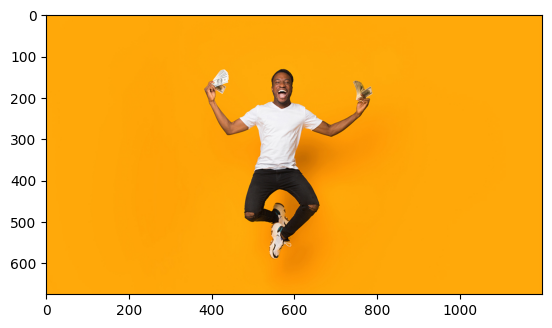

In [ ]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
      image_path = os.path.join(data_dir, image_class, image)
      try:
        img = cv2.imread(image_path)
        tip = imghdr.what(image_path)
        if tip not in image_exts:
          print('Image not in ext list {}'.format(image_path))
          os.remove(image_path)
      except Exception as e:
        print('Issue with image {}'.format(image_path))

**1.3 Load Data**

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
data = tf.keras.utils.image_dataset_from_directory(data_dir)

Found 298 files belonging to 2 classes.


In [ ]:
data_iterator = data.as_numpy_iterator()

In [ ]:
data_iterator

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x79ea4dd5ec60>)

In [ ]:
batch = data_iterator.next()

In [ ]:
# Images respresented as numpy arrays
batch[0].shape

(32, 256, 256, 3)

In [ ]:
# Class 1 = SAD PPL
# Class 0 = HAPPY PPL
batch[1]

array([0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1], dtype=int32)

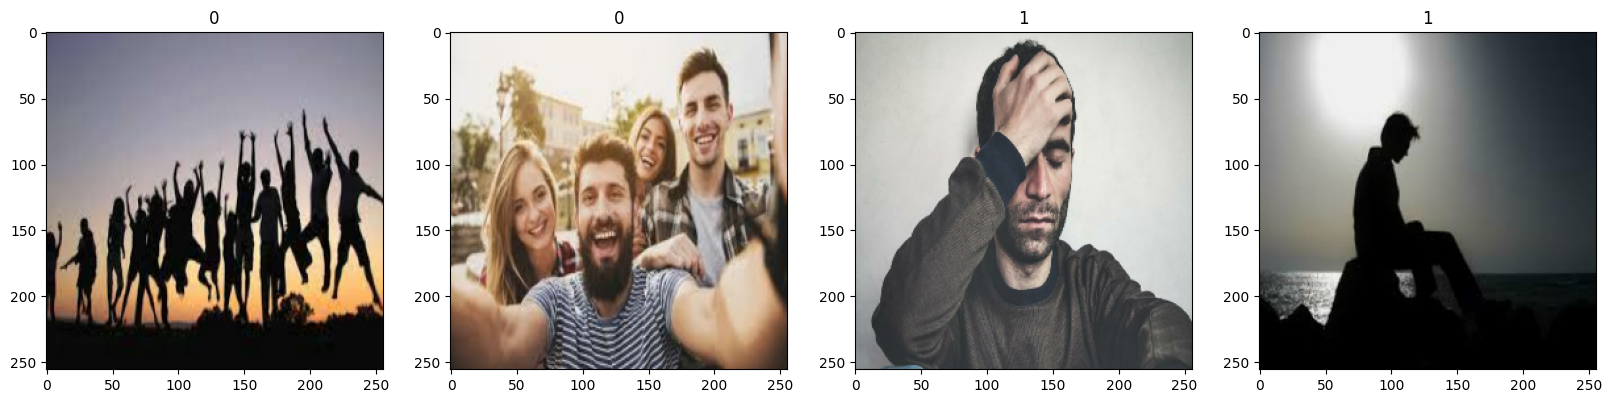

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
  ax[idx].imshow(img.astype(int))
  ax[idx].title.set_text(batch[1][idx])

In [ ]:
scaled = batch[0] / 255

In [ ]:
scaled.max()

np.float32(1.0)

# **2. Preprocess Data**

**2.1 Scale Data**

In [ ]:
data = data.map(lambda x,y: (x/255, y)) # x image y label remember len=2

In [ ]:
scaled_iterator = data.as_numpy_iterator()

In [ ]:
batch = scaled_iterator.next()

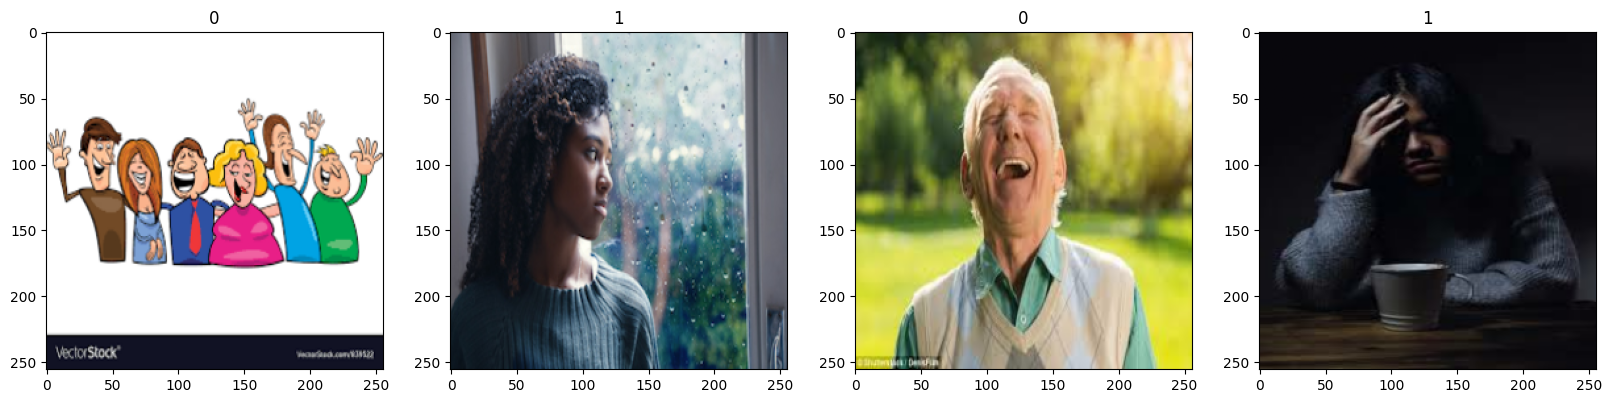

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
  ax[idx].imshow(img)
  ax[idx].title.set_text(batch[1][idx])

**2.2 Split Data**

In [ ]:
len(data) # number of batches

10

In [ ]:
# Split data
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [ ]:
train_size + val_size + test_size

10

In [ ]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [ ]:
len(test)

1

# **3. Deep Model**

**3.1 Build Deep Learning Model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

In [ ]:
model = Sequential()

In [ ]:
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

**3.2 Train**

In [ ]:
logdir='logs'

In [ ]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [ ]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.5670 - loss: 1.4980 - val_accuracy: 0.4688 - val_loss: 0.9629
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5759 - loss: 0.7075 - val_accuracy: 0.4844 - val_loss: 0.6646
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5625 - loss: 0.6640 - val_accuracy: 0.8281 - val_loss: 0.6533
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7188 - loss: 0.5923 - val_accuracy: 0.6406 - val_loss: 0.5846
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7500 - loss: 0.5465 - val_accuracy: 0.8281 - val_loss: 0.4552
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8438 - loss: 0.4547 - val_accuracy: 0.6875 - val_loss: 0.5595
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.8527 - loss: 0.4161 - val_accuracy: 0.8438 - val_loss: 0.3359
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8795 - loss: 0.2801 - val_accuracy: 0.9062 - val_loss: 0.2049
Epoch 9/

**3.3 Plot Performance**

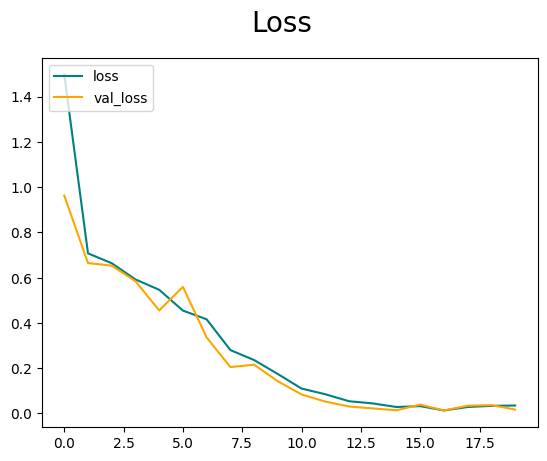

In [ ]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

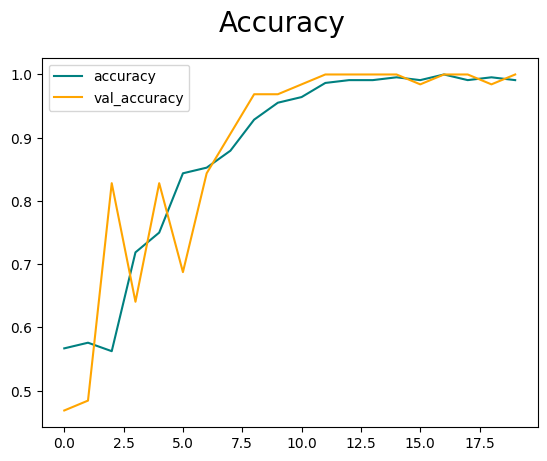

In [ ]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# **4. Evaluate**

**4.1 Evaluate**

In [ ]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [ ]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [ ]:
for batch in test.as_numpy_iterator():
  X, y = batch
  yhat = model.predict(X)
  pre.update_state(y, yhat)
  re.update_state(y, yhat)
  acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step


In [ ]:
print(f'Precision:{pre.result().numpy()}, Recall:{re.result().numpy()}, Accuracy:{acc.result().numpy()}')

Precision:1.0, Recall:1.0, Accuracy:1.0


**4.2 Test**

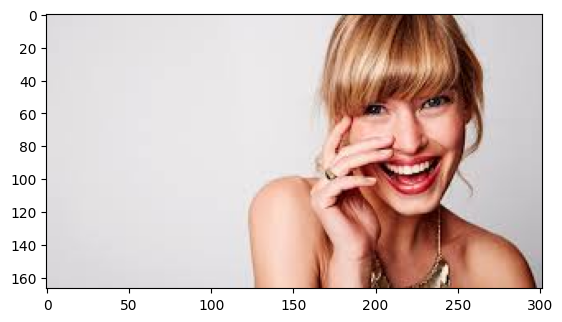

In [72]:
img = cv2.imread('happytest.jpeg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

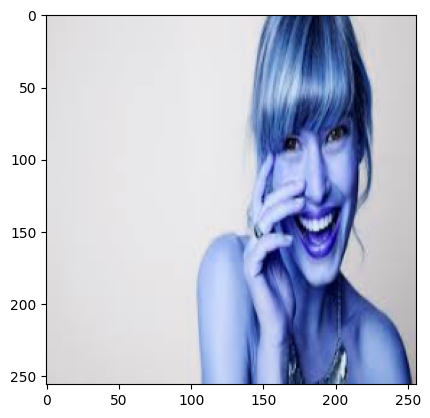

In [75]:
resize = tf.image.resize(img, (256, 256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [76]:
np.expand_dims(resize, 0) #model accept batch so we encapsulate this into another set of array

array([[[[221.      , 218.      , 220.      ],
         [221.26953 , 218.26953 , 220.26953 ],
         [222.      , 219.      , 221.      ],
         ...,
         [209.      , 206.      , 208.      ],
         [209.      , 206.      , 208.      ],
         [209.      , 206.      , 208.      ]],

        [[221.      , 218.      , 220.      ],
         [221.26953 , 218.26953 , 220.26953 ],
         [222.      , 219.      , 221.      ],
         ...,
         [209.      , 206.      , 208.      ],
         [209.      , 206.      , 208.      ],
         [209.      , 206.      , 208.      ]],

        [[221.      , 218.      , 220.      ],
         [221.26953 , 218.26953 , 220.26953 ],
         [222.      , 219.      , 221.      ],
         ...,
         [209.      , 206.      , 208.      ],
         [209.      , 206.      , 208.      ],
         [209.      , 206.      , 208.      ]],

        ...,

        [[215.      , 212.      , 214.      ],
         [215.      , 212.      , 214.      ]

In [80]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


In [81]:
yhat

array([[0.53259003]], dtype=float32)

In [82]:
if yhat > 0.5:
  print(f'Predicted class is Sad')
else:
  print(f'Predicted class is Happy')

Predicted class is Sad


# **5. Save the Model**

**5.1 Save the Model**

In [83]:
from tensorflow.keras.models import load_model

In [84]:
model.save(os.path.join('models', 'happysadmodel.h5'))

In [85]:
new_model = load_model(os.path.join('models', 'happysadmodel.h5'))

In [88]:
yhatnew = new_model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


In [89]:
if yhatnew > 0.5:
  print(f'Predicted class is Sad')
else:
  print(f'Predicted class is Happy')

Predicted class is Sad
